### 1. Data Dictionary
- age (usia): Usia pasien dalam satuan tahun.
- sex (jenis kelamin): Jenis kelamin pasien.

    - 1 = laki-laki
    - 0 = perempuan

- cp (tipe nyeri dada): Jenis nyeri dada yang dialami pasien.

    - 0 = angina tipikal (typical angina)
    - 1 = angina atipikal (atypical angina)
    - 2 = nyeri non-angina (non-anginal pain)
    - 3 = tanpa gejala (asymptomatic)

- trestbps (tekanan darah saat istirahat): Tekanan darah pasien saat istirahat, diukur dalam satuan mmHg ketika pasien masuk rumah sakit.

- chol (kolesterol): Kadar kolesterol serum pasien dalam satuan mg/dL.

- fbs (gula darah puasa): Menunjukkan apakah kadar gula darah puasa pasien lebih besar dari 120 mg/dL.

    - 1 = benar, gula darah puasa lebih dari 120 mg/dL
    - 0 = salah, gula darah puasa tidak lebih dari 120 mg/dL

- restecg (hasil elektrokardiografi saat istirahat): Hasil pemeriksaan elektrokardiografi atau EKG pasien dalam kondisi istirahat.

    - 0 = normal
    - 1 = terdapat kelainan gelombang ST-T, berupa inversi gelombang T dan/atau elevasi atau depresi segmen ST lebih dari 0,05 mV
    - 2 = menunjukkan kemungkinan atau kepastian hipertrofi ventrikel kiri berdasarkan kriteria Estes

- thalach (denyut jantung maksimum): Denyut jantung maksimum yang berhasil dicapai pasien.

- exang (angina akibat olahraga): Menunjukkan apakah pasien mengalami angina atau nyeri dada yang dipicu oleh aktivitas fisik.

    - 1 = ya
    - 0 = tidak

- oldpeak (depresi segmen ST): Besarnya depresi segmen ST yang dipicu oleh aktivitas fisik dibandingkan dengan kondisi istirahat.

- slope (kemiringan segmen ST): Bentuk kemiringan segmen ST pada puncak aktivitas fisik.

    - 0 = menanjak (upsloping)
    - 1 = datar (flat)
    - 2 = menurun (downsloping)

- ca (jumlah pembuluh darah utama): Jumlah pembuluh darah utama yang terlihat atau terwarnai melalui pemeriksaan fluoroskopi, dengan rentang nilai 0–3.

- thal (hasil pemeriksaan thalium): Kategori kondisi berdasarkan hasil pemeriksaan thalium stress test.

    - 0 = kesalahan atau data tidak valid. Pada dataset asli, nilai ini dipetakan sebagai nilai kosong atau NaN
    - 1 = cacat tetap (fixed defect)
    - 2 = normal
    - 3 = cacat reversibel (reversible defect)

- target (label/status penyakit): Variabel keluaran yang menunjukkan status penyakit jantung pasien.

    - 0 = tidak terindikasi penyakit jantung
    - 1 = terindikasi penyakit jantung

### 1. Import library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
data = pd.read_csv("heart_disease_dataset.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
data.shape

(1025, 14)

In [26]:
data.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


Berdasarkan hasil data.describe(), dataset terdiri atas 1.025 observasi dengan rata-rata usia pasien 54,43 tahun. Tekanan darah saat istirahat memiliki rata-rata 131,61 mmHg, kadar kolesterol rata-rata 246 mg/dL, dan denyut jantung maksimum rata-rata 149,11 denyut per menit. Sekitar 15% observasi memiliki gula darah puasa di atas 120 mg/dL dan sekitar 34% mengalami angina akibat aktivitas fisik. Beberapa atribut kontinu, terutama chol, trestbps, dan oldpeak, memiliki nilai maksimum yang cukup jauh dari kuartil ketiga sehingga perlu diperiksa lebih lanjut sebagai kemungkinan outlier. Selain itu, terdapat nilai thal = 0 yang menurut kamus data merupakan nilai tidak valid serta nilai maksimum ca = 4 yang berada di luar rentang 0 sampai 3 pada kamus data. Oleh karena itu, pemeriksaan distribusi, nilai unik, frekuensi kategori, dan outlier perlu dilakukan sebelum menganalisis hubungan setiap atribut dengan variabel target.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
data.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Hasil data.info() dan data.isna() menunjukkan bahwa dataset memiliki 1.025 baris dan 14 kolom. Seluruh kolom berisi 1.025 data non-null, sehingga tidak ditemukan nilai kosong. Dataset terdiri atas 13 kolom bertipe int64 dan satu kolom bertipe float64, yaitu oldpeak. Namun, tidak semua kolom bertipe integer merupakan variabel numerik karena beberapa atribut, seperti sex, cp, fbs, restecg, exang, slope, ca, thal, dan target, merupakan kategori yang dikodekan dalam bentuk angka. Dataset ini memiliki struktur yang cukup lengkap untuk dilanjutkan ke tahap EDA berikutnya.

In [ ]:
data_duplikat = data.duplicated().sum()
print(data_duplikat)

723


In [35]:
data_raw = data.copy()
data_clean = data.drop_duplicates().copy()
perbandingan_target = pd.concat(
    [
        data_raw["target"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .rename("Sebelum (%)"),

        data_clean["target"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .rename("Sesudah (%)")
    ],
    axis=1
).round(2)

perbandingan_target

,Sebelum (%),Sesudah (%)
target,,
0,48.68,45.7
1,51.32,54.3


Dataset awal mengandung 723 baris duplikat dari 1.025 observasi dan menyisakan 302 observasi unik setelah penghapusan duplikat. Sebelum pembersihan, proporsi target = 0 dan target = 1 masing-masing sebesar 48,68% dan 51,32%. Setelah duplikat dihapus, proporsinya berubah menjadi 45,70% dan 54,30%. Dengan demikian, terjadi perubahan sebesar 2,98 poin persentase pada masing-masing kelas. Penghapusan duplikat tidak membalik dominasi kelas, tetapi memperbesar selisih proporsi antara kedua kelompok. Meskipun demikian, distribusi target setelah pembersihan masih relatif tidak timpang secara ekstrem sehingga tetap memadai untuk analisis eksploratif lebih lanjut.

target
1    164
0    138
Name: count, dtype: int64
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


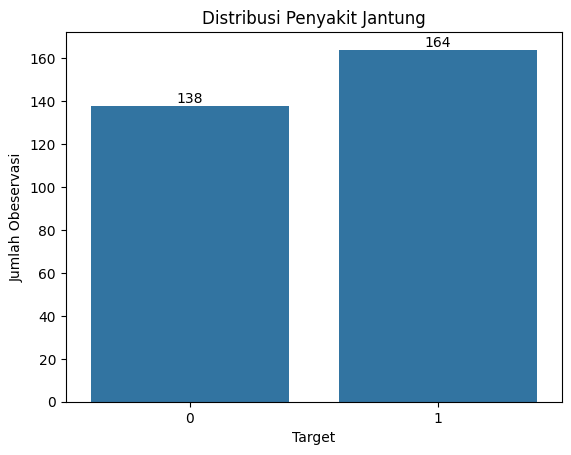

In [40]:
ax = sns.countplot(data=data_clean, x="target")

plt.title("Distribusi Penyakit Jantung")
plt.xlabel("Target")
plt.ylabel("Jumlah Obeservasi")

for container in ax.containers:
    ax.bar_label(container)
    
plt.show
print(data_clean["target"].value_counts())
print(data_clean["target"].value_counts(normalize=True)*100)

In [42]:
categorical_cols = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"
]

for col in categorical_cols:
    print(f"\nDistribusi {col}")
    print(data_clean[col].value_counts(dropna=False).sort_index())


Distribusi sex
sex
0     96
1    202
Name: count, dtype: int64

Distribusi cp
cp
0    142
1     49
2     84
3     23
Name: count, dtype: int64

Distribusi fbs
fbs
0    254
1     44
Name: count, dtype: int64

Distribusi restecg
restecg
0    146
1    148
2      4
Name: count, dtype: int64

Distribusi exang
exang
0    200
1     98
Name: count, dtype: int64

Distribusi slope
slope
0     21
1    138
2    139
Name: count, dtype: int64

Distribusi ca
ca
0    175
1     65
2     38
3     20
Name: count, dtype: int64

Distribusi thal
thal
0      2
1     18
2    163
3    115
Name: count, dtype: int64

Distribusi target
target
0    137
1    161
Name: count, dtype: int64


Berdasarkan 302 observasi unik, dataset didominasi oleh pasien berkode laki-laki sebesar 68,21%. Tipe nyeri dada paling banyak adalah cp = 0 sebanyak 47,35%, sedangkan 85,10% observasi memiliki gula darah puasa tidak lebih dari 120 mg/dL. Sebanyak 67,22% observasi tidak mengalami angina akibat aktivitas fisik. Kategori slope = 1 dan slope = 2 memiliki proporsi yang hampir sama, masing-masing 46,36% dan 46,69%. Pada atribut ca, mayoritas observasi memiliki nilai 0 sebesar 57,95%, tetapi ditemukan empat observasi dengan ca = 4 yang berada di luar rentang data dictionary. Pada atribut thal, kategori normal mendominasi sebesar 54,64%, tetapi terdapat dua nilai thal = 0 yang perlu diperlakukan sebagai data tidak valid. Variabel target relatif seimbang, yaitu 45,70% tidak terindikasi dan 54,30% terindikasi penyakit jantung. Hasil ini menunjukkan bahwa analisis selanjutnya dapat berfokus pada perbandingan proporsi setiap kategori terhadap target.

In [41]:
data_clean = data_clean[data_clean["ca"] < 4]

Atribut ca menunjukkan jumlah pembuluh darah utama yang terwarnai atau terlihat melalui pemeriksaan fluoroskopi. Berdasarkan data dictionary, nilai yang valid berada pada rentang 0 sampai 3. Oleh karena itu, value yang lebih dari 3 saya drop.

In [47]:
numeric_cols = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]
data_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,298.0,54.510067,9.030526,29.0,48.0,56.0,61.00,77.0
trestbps,298.0,131.580537,17.669293,94.0,120.0,130.0,140.00,200.0
chol,298.0,246.906040,51.893097,126.0,211.0,241.5,275.00,564.0
thalach,298.0,149.466443,22.983830,71.0,133.0,152.5,165.75,202.0
oldpeak,298.0,1.055369,1.164162,0.0,0.0,0.8,1.60,6.2


Berdasarkan 298 observasi yang dianalisis, rata-rata usia pasien adalah 54,51 tahun, dengan mayoritas usia berada antara 48 dan 61 tahun. Tekanan darah saat istirahat memiliki rata-rata 131,58 mmHg, sedangkan kadar kolesterol memiliki rata-rata 246,91 mg/dL. Denyut jantung maksimum rata-rata mencapai 149,47 denyut per menit dan nilai oldpeak rata-rata sebesar 1,06. Atribut chol, trestbps, dan oldpeak memiliki nilai maksimum yang relatif jauh dari kuartil ketiga, sehingga mengindikasikan kemungkinan adanya nilai ekstrem. Pemeriksaan lebih lanjut menggunakan boxplot dan metode IQR diperlukan untuk menentukan jumlah serta posisi outlier. Nilai ekstrem tidak langsung dihapus karena dalam data klinis nilai tersebut masih mungkin merepresentasikan kondisi pasien yang valid.

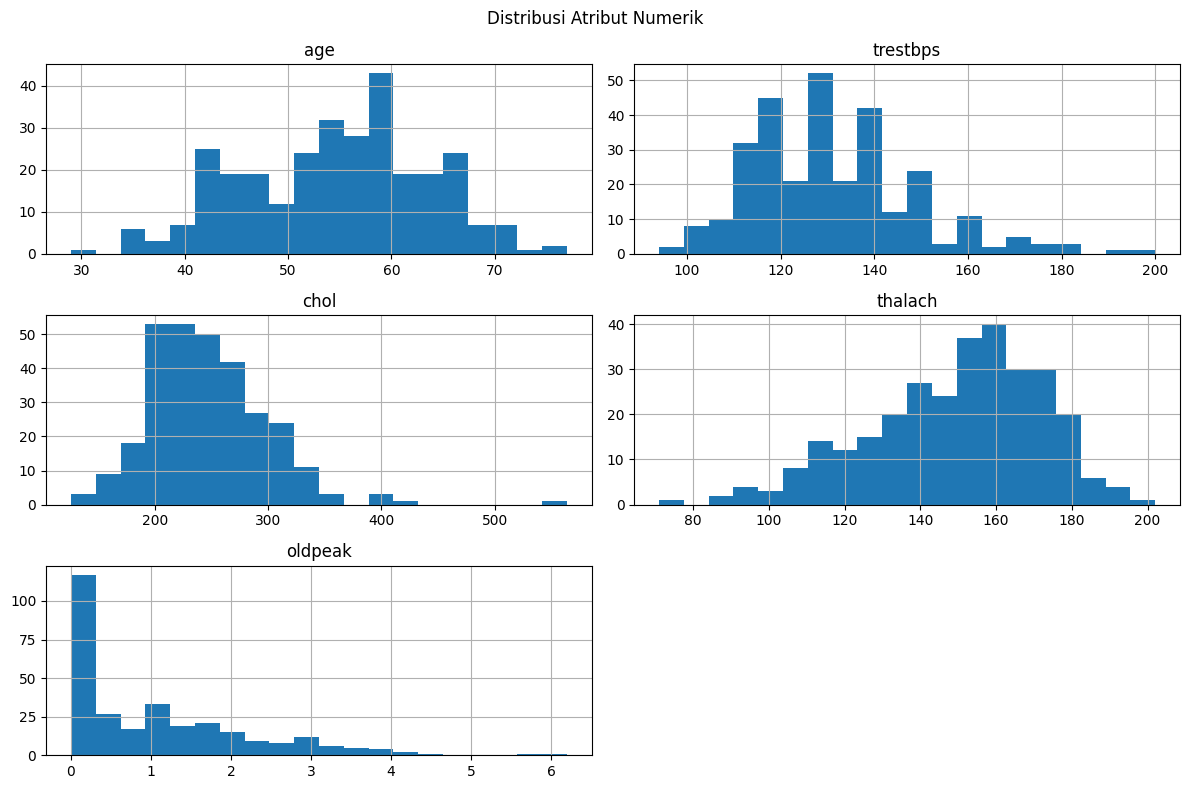

In [46]:
data_clean[numeric_cols].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribusi Atribut Numerik")
plt.tight_layout()
plt.show()

Histogram menunjukkan bahwa atribut age dan thalach memiliki distribusi yang relatif terpusat, dengan mayoritas pasien berusia sekitar 45–65 tahun dan mencapai denyut jantung maksimum sekitar 130–180 denyut per menit. Distribusi trestbps sedikit miring ke kanan karena terdapat beberapa nilai tekanan darah tinggi hingga 200 mmHg. Atribut chol juga menunjukkan kemencengan ke kanan, dengan mayoritas nilai berada sekitar 180–300 mg/dL dan beberapa nilai ekstrem hingga 564 mg/dL. Distribusi paling tidak simetris terlihat pada oldpeak, karena sebagian besar observasi berada pada nilai rendah atau nol, sedangkan sebagian kecil observasi memanjang hingga 6,20. Pola tersebut menunjukkan adanya kemungkinan nilai ekstrem pada trestbps, chol, dan oldpeak, tetapi penetapan outlier perlu dikonfirmasi menggunakan boxplot dan metode IQR. Nilai ekstrem tidak langsung dihapus karena masih dapat merepresentasikan kondisi pasien yang valid.

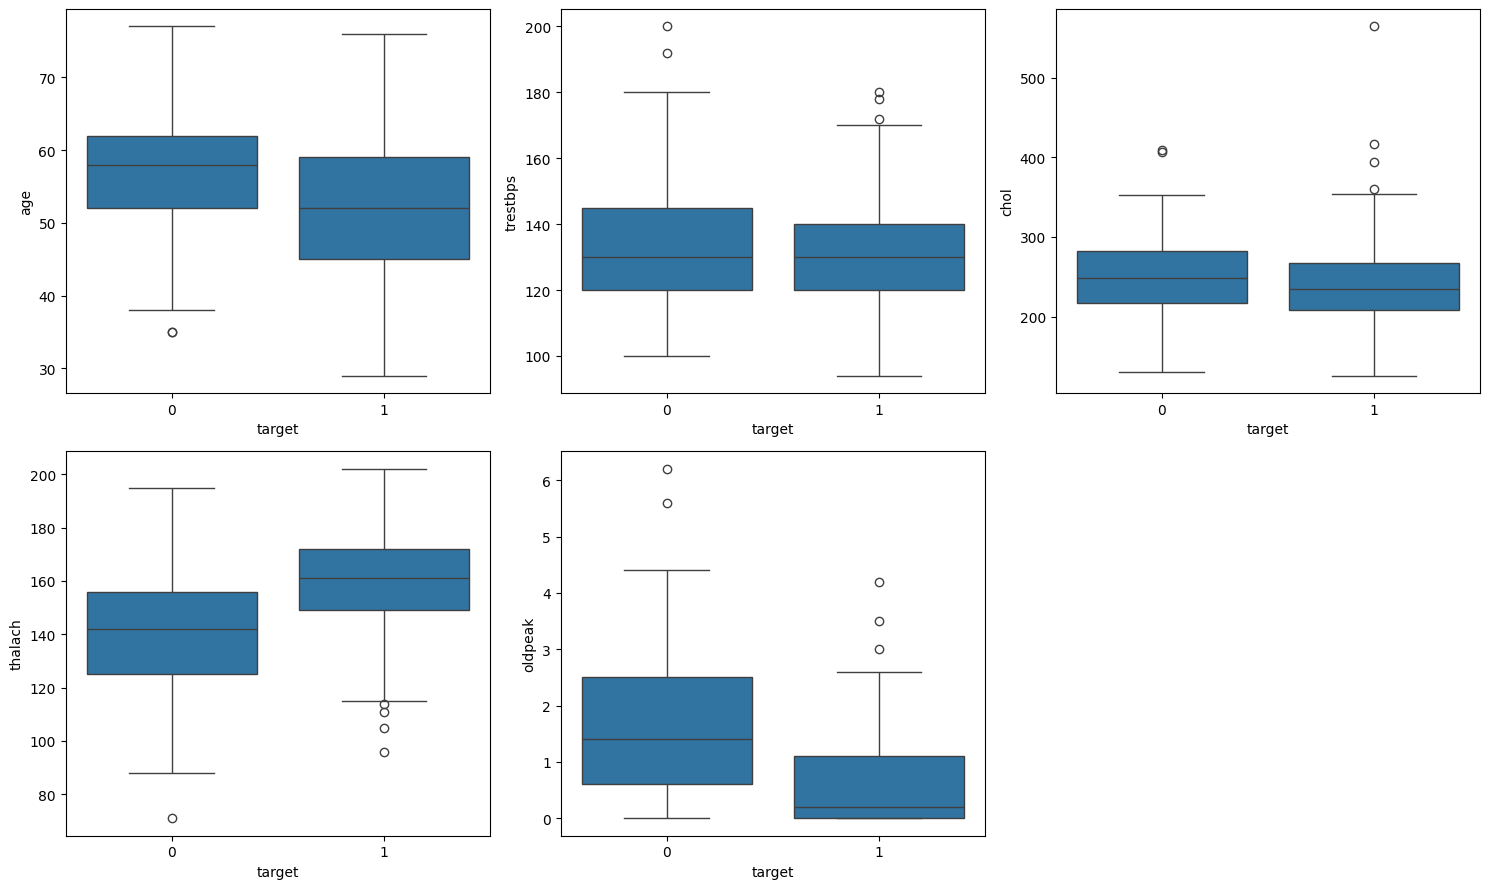

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=data_clean,
        x="target",
        y=col,
        ax=axes[i]
    )

axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [54]:
continuous_cols = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

outlier_summary = []

for col in continuous_cols:
    q1 = data_clean[col].quantile(0.25)
    q3 = data_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    total_outlier = (
        (data_clean[col] < lower) |
        (data_clean[col] > upper)
    ).sum()

    outlier_summary.append({
        "Atribut": col,
        "Batas bawah": lower,
        "Batas atas": upper,
        "Jumlah outlier": total_outlier
    })

pd.DataFrame(outlier_summary)

,Atribut,Batas bawah,Batas atas,Jumlah outlier
0,age,28.500,80.500,0
1,trestbps,90.000,170.000,9
2,chol,115.000,371.000,5
3,thalach,83.875,214.875,1
4,oldpeak,-2.400,4.000,5


Boxplot pada data yang telah dibersihkan menunjukkan bahwa thalach dan oldpeak memiliki perbedaan distribusi paling jelas berdasarkan variabel target. Kelompok target = 1 memiliki median thalach lebih tinggi daripada kelompok target = 0, sedangkan kelompok target = 0 memiliki median oldpeak lebih tinggi. Median usia kelompok target = 0 juga terlihat lebih tinggi dibandingkan kelompok target = 1. Sementara itu, median dan distribusi trestbps pada kedua kelompok hampir sama, sedangkan chol memiliki tumpang tindih distribusi yang besar meskipun median kelompok target = 0 sedikit lebih tinggi. Calon outlier ditemukan pada seluruh atribut numerik, tetapi tidak langsung dihapus karena masih mungkin merepresentasikan kondisi pasien yang valid. Secara keseluruhan, thalach dan oldpeak merupakan atribut numerik yang paling menunjukkan pola perbedaan berdasarkan target dalam dataset ini.

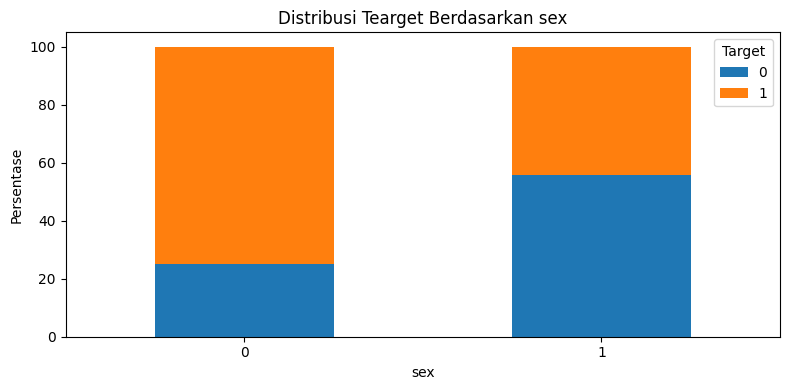

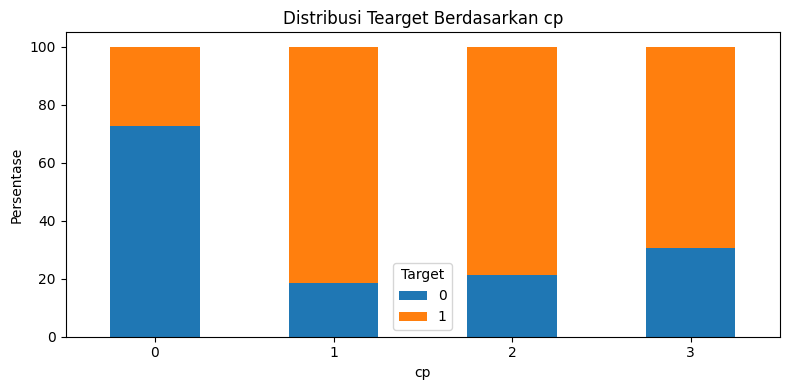

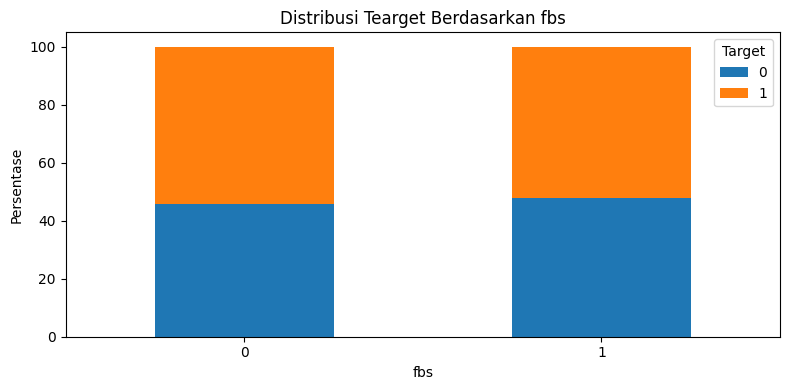

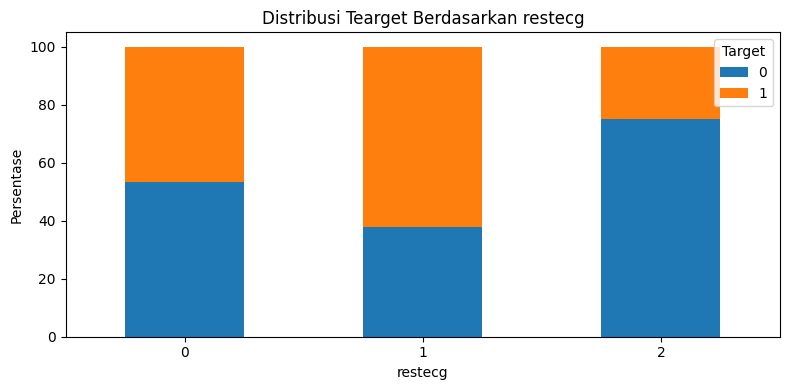

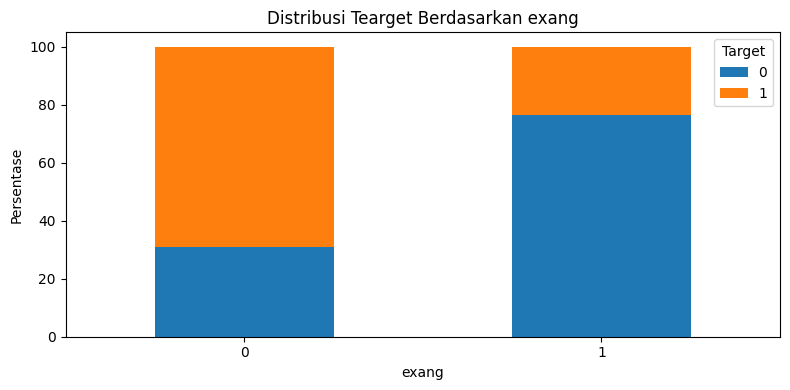

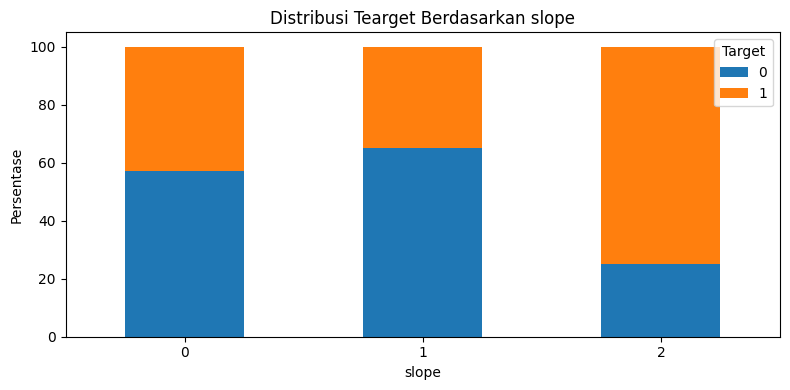

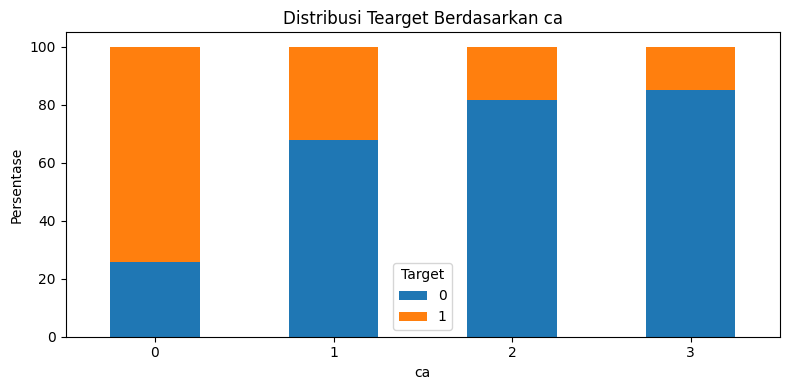

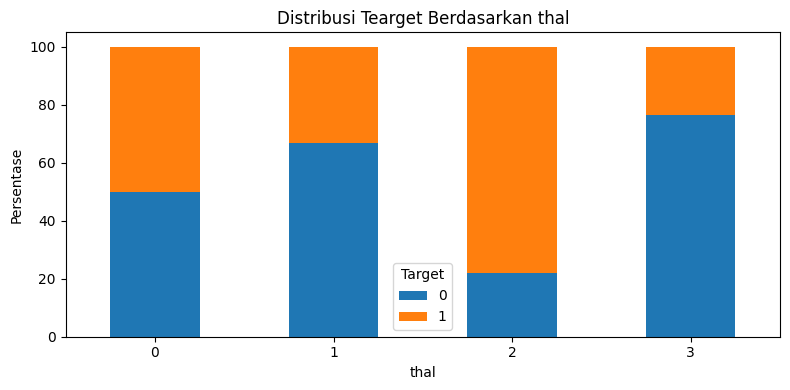

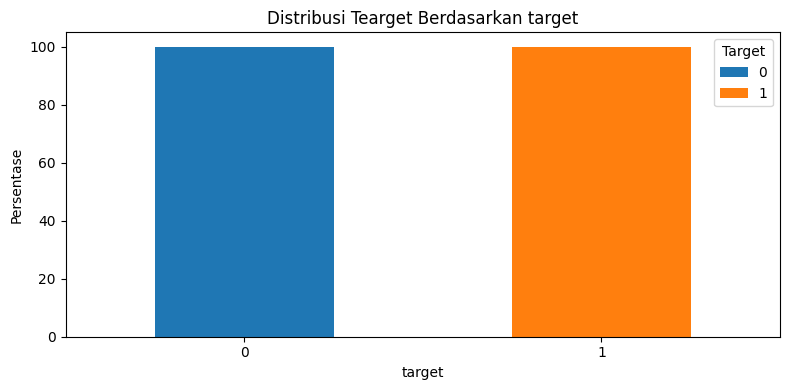

In [51]:
categorical_cols = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"
]

for col in categorical_cols:
    proporsi = pd.crosstab(data_clean[col], data_clean["target"], normalize="index") * 100
    proporsi.plot(kind="bar", stacked=True, figsize= (8, 4))
    
    plt.title(f"Distribusi Tearget Berdasarkan {col}")
    plt.xlabel(col)
    plt.ylabel("Persentase")
    plt.xticks(rotation=0)
    plt.legend(
        title="Target",
        labels=["0", "1"]
    )
    plt.tight_layout()
    plt.show()

Setelah menggunakan data_clean, atribut cp, exang, slope, ca, dan thal memperlihatkan perbedaan proporsi target paling jelas. Kelompok target = 1 lebih dominan pada cp = 1, cp = 2, exang = 0, slope = 2, ca = 0, dan thal = 2. Sebaliknya, kelompok target = 0 lebih dominan pada cp = 0, exang = 1, slope = 1, ca = 1–3, dan thal = 3. Atribut fbs memiliki distribusi target yang hampir sama pada kedua kategori sehingga secara visual menunjukkan pola hubungan yang lebih lemah. Nilai ca = 4 sudah tidak muncul setelah proses pembersihan, tetapi thal = 0 masih terlihat dan perlu diperlakukan sebagai nilai tidak valid atau nilai hilang terselubung. Visualisasi target berdasarkan target sebaiknya dihapus karena tidak menghasilkan informasi baru.

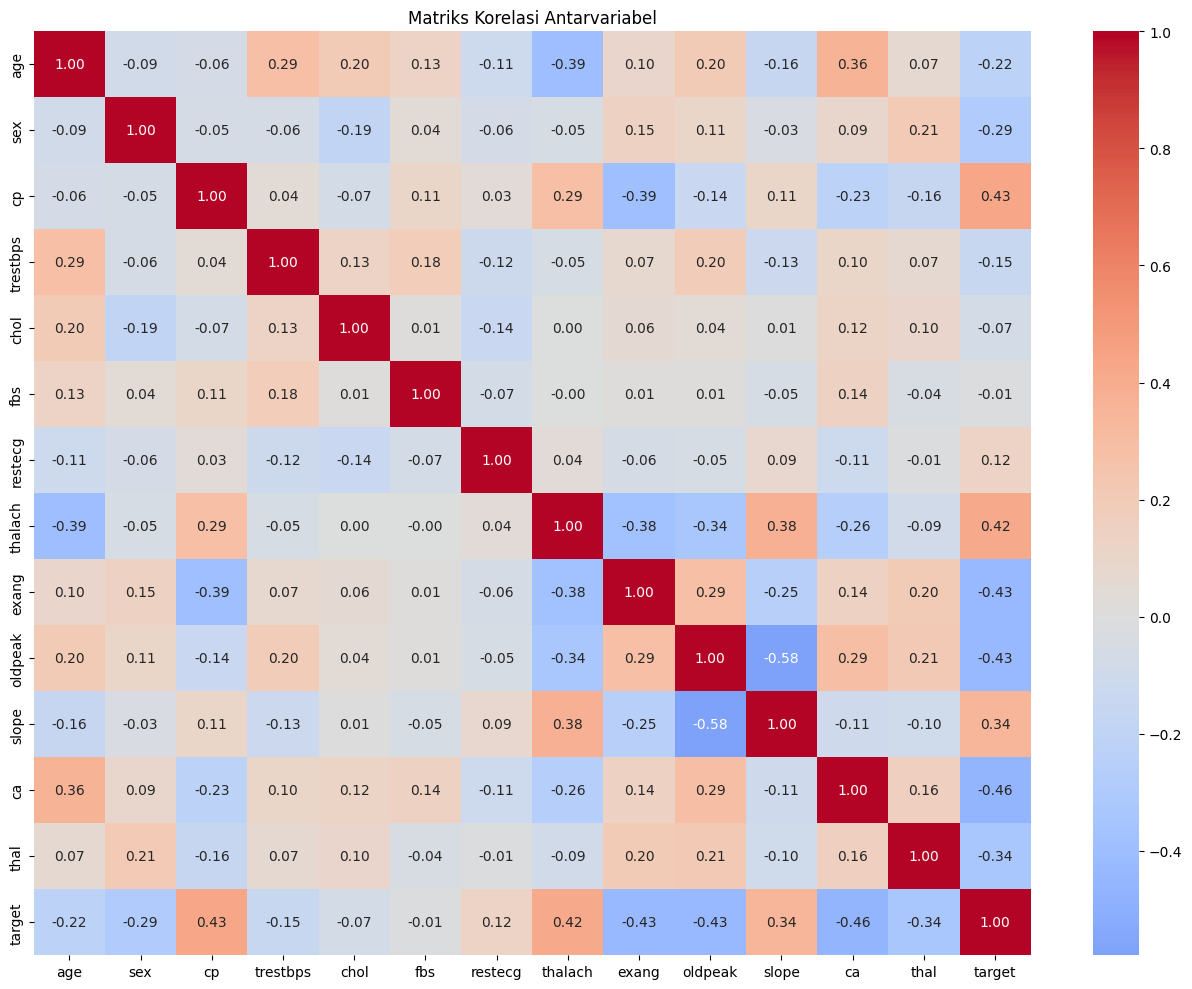

In [52]:
plt.figure(figsize=(13, 10))
corr = data_clean.corr(numeric_only=True)
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Matriks Korelasi Antarvariabel")
plt.tight_layout()
plt.show()

Matriks korelasi menunjukkan bahwa atribut dengan hubungan paling besar terhadap target adalah ca sebesar −0,46, diikuti oleh cp sebesar 0,43, exang sebesar −0,43, oldpeak sebesar −0,43, dan thalach sebesar 0,42. Atribut slope dan thal juga menunjukkan hubungan yang cukup terlihat, masing-masing sebesar 0,34 dan −0,34. Sebaliknya, fbs, chol, restecg, dan trestbps memiliki korelasi yang sangat lemah terhadap target. Korelasi antarf fitur paling besar ditemukan antara oldpeak dan slope, yaitu −0,58. Secara keseluruhan, tidak ada satu atribut yang memiliki korelasi sangat kuat dengan target. Hal ini menunjukkan bahwa status penyakit jantung dalam dataset kemungkinan berkaitan dengan kombinasi beberapa atribut, bukan hanya satu atribut secara individual. Namun, hasil korelasi hanya menunjukkan hubungan linear dan tidak membuktikan hubungan sebab-akibat.